# Анализ и прогнозирование данных платежей

Анализируем данные по платежам от доноров в адрес фондов, прогнозируем суммы платежей в различных формах - суммарно на следующий день, следующую неделю, следующий месяц, также с группировкой по различным описательным признакам (фонды, провайдеры платежей, тип подписки, категории платежей).

Иследовательский анализ исключили (он будет дополняться в самом первом файле - first_try_origin.ipynb).

На **данном** этапе данные подготовлены для прогнозирования сумм на следующий день методом SARIMAX (для временного ряда) как промежуточный вариант, который будет использоваться для генерации доппризнака при обучении модели на базе catboost. Данный пункт будет дополняться.

<a id='К-содержанию'></a>
**Содержание проекта**

[Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)\
[Подготовка и агрегирование данных](#Подготовка-и-агрегирование-данных)\
[Обучение SARIMAX](#Обучение-SARIMAX)\
[Тестирование модели](#Тестирование-модели)

In [1]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# загружаем класс pipeline и классы дя подготовки данных и запуска пайплайна
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from tqdm import notebook
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# загружаем нужные модели и метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.dummy import DummyRegressor


# загружаем библиотеки для Pytorch и предобученных моделей
import torch

In [2]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

# cоздаём метрику smape
smape_scorer = make_scorer(smape, greater_is_better=False)

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [3]:
# импортируем тренировочные данные
pth1 = 'data.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
else:
    print('Something is wrong')

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360258 entries, 0 to 360257
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   fund_id     360258 non-null  int64  
 1   full_sum    360258 non-null  float64
 2   date        360258 non-null  int64  
 3   provider    360258 non-null  int64  
 4   signup      360258 non-null  int64  
 5   category_1  360258 non-null  int64  
 6   category_2  360258 non-null  int64  
 7   category_3  360258 non-null  int64  
 8   category_4  360258 non-null  int64  
 9   category_5  360258 non-null  int64  
 10  category_6  360258 non-null  int64  
 11  category_7  360258 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 33.0 MB


,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0


In [4]:
# посмотрим распределение меток по категориям
cat_columns = ['category_1', 'category_2', 'category_3', 'category_4', 'category_5', 'category_6', 'category_7']

data['cat_columns_sum'] = data[cat_columns].sum(axis=1)
display(data['cat_columns_sum'].value_counts())

data = data.drop(['cat_columns_sum'],axis=1)

cat_columns_sum
0    321861
1     21656
2     10219
3      6522
Name: count, dtype: int64

In [5]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

# уберем дубликаты и пропуски
data = data.drop_duplicates()
data = data.dropna()

Количество дубликатов:  2989
Количество пропусков:  0


In [6]:
# исключаем мегавыбросы (платежи более порога TRESHOLD_CONST) 
# для более адекватного обучения модели 

TRESHOLD_CONST = 0.95

threshold = data['full_sum'].quantile(TRESHOLD_CONST)
data = data[data['full_sum']<=threshold]

Выловили порядка 3 тысяч дубликатов, что с одной стороны маловероятно - одинаковые платежи в одну и ту же секунду, но, возможно, банк обработал платежи одним пакетом, с точки зрения обучения дубликаты не несут дополнительной информации, поэтому их удалили.
Выбросы на суммы платежей более порога 95%-перцентиля рублей также исключили.


In [7]:
# по датам добавим столбец в наглядном формате datetime
data['datetime'] = pd.to_datetime(data['date'], unit='s')
data = data.drop('date', axis=1)

data.head() 

,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
0,44,500.00,4,0,0,0,0,0,0,0,0,2017-10-19 06:15:17
1,88,200.00,4,0,0,0,0,0,0,0,0,2017-10-19 07:52:08
2,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:25
3,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:43
4,1,20.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:01:28


<a id='Подготовка-и-агрегирование-данных'></a> 
## Подготовка и агрегирование данных
[К содержанию](#К-содержанию)

In [8]:
# выберем фонд
data_fund = data.loc[data['fund_id']==136].copy() #136

data_fund.info()
data_fund.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3924 entries, 527 to 360131
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fund_id     3924 non-null   int64         
 1   full_sum    3924 non-null   float64       
 2   provider    3924 non-null   int64         
 3   signup      3924 non-null   int64         
 4   category_1  3924 non-null   int64         
 5   category_2  3924 non-null   int64         
 6   category_3  3924 non-null   int64         
 7   category_4  3924 non-null   int64         
 8   category_5  3924 non-null   int64         
 9   category_6  3924 non-null   int64         
 10  category_7  3924 non-null   int64         
 11  datetime    3924 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 398.5 KB


,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,136,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44
708,136,200.00,1,1,0,0,1,0,0,0,0,2017-10-20 14:40:08
15185,136,200.00,1,1,0,0,1,0,0,0,0,2017-11-02 14:19:13
15535,136,400.00,1,0,0,0,1,0,0,0,0,2017-11-02 22:45:43
16267,136,1000.00,1,0,0,0,1,0,0,0,0,2017-11-03 17:35:34


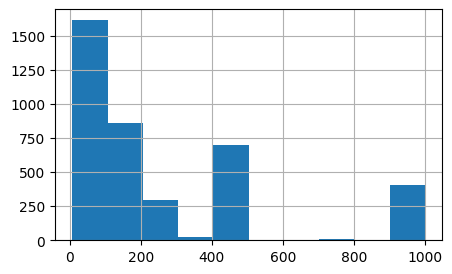

In [9]:
data_fund['full_sum'].hist(bins=10,figsize=(5, 3));

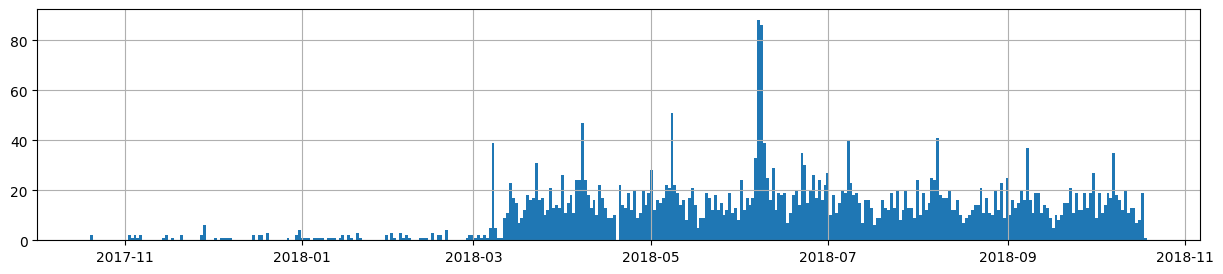

In [10]:
data_fund['datetime'].dt.date.hist(bins=366, figsize=(15, 3));

In [11]:
# проверяем монотонность и сортируем при необходимости
if not data_fund['datetime'].is_monotonic_increasing:
    data_fund = data_fund.sort_values('datetime')

# создаем столбец с датой из формата datetime для использования в индексе
data_fund['date'] = data_fund['datetime'].dt.date

# убираем все лишние столбцы из датафрейма, для целей SARIMAX будем использовать только целевое значение сумм поступлений
data_fund = data_fund.drop(['fund_id','datetime','provider', 'signup', 'category_1',
       'category_2', 'category_3', 'category_4', 'category_5', 'category_6',
       'category_7'], axis=1)

# делаем агрегацию по дате
aggregated_data_fund = data_fund.groupby('date')['full_sum'].sum()
aggregated_data_fund.index.name = None

display(aggregated_data_fund.shape)
aggregated_data_fund.head(1)

(289,)

2017-10-20   300.00
Name: full_sum, dtype: float64

In [12]:
# создаем полный диапазон дат
full_date_range = pd.date_range(
    start=aggregated_data_fund.index.min(),
    end=aggregated_data_fund.index.max(),
    freq='D'
)

# переиндексируем данные и заполним пропуски
y_filled = aggregated_data_fund.reindex(full_date_range, fill_value=0)

display(y_filled.shape)
y_filled.head(1)

(365,)

2017-10-20   300.00
Freq: D, Name: full_sum, dtype: float64

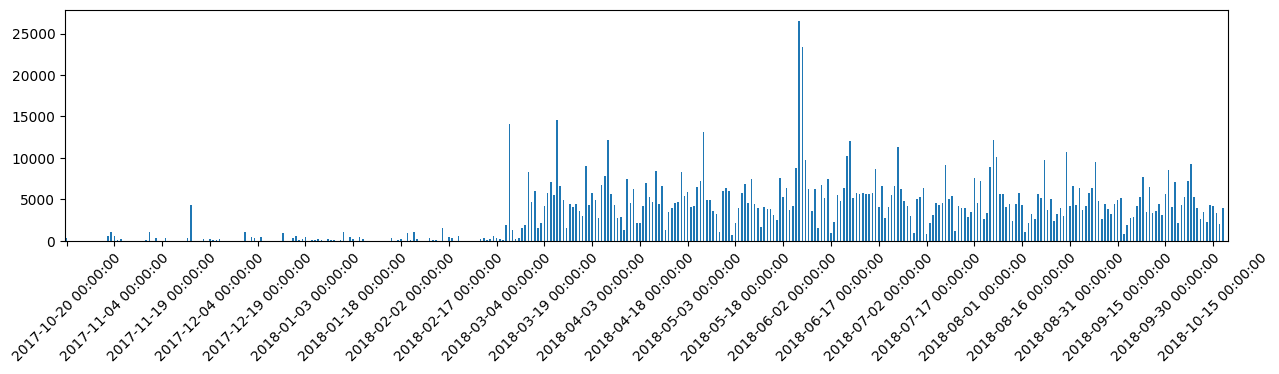

In [13]:
ax = y_filled.plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  #настраиваем подписи на оси x
plt.xticks(rotation=45)

plt.show()

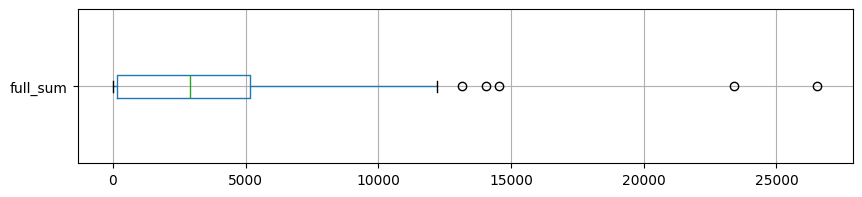

In [14]:
y_filled.to_frame().boxplot(figsize=(10, 2), vert=False);

In [15]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
threshold = y_filled.quantile(TRESHOLD_CONST)
print(threshold)
mean_full_sum = y_filled.median()
print(mean_full_sum)

y_filled.loc[y_filled > threshold] = mean_full_sum

8919.200000000003
2901.0


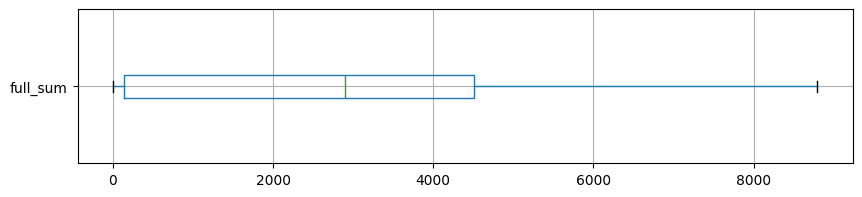

In [16]:
y_filled.to_frame().boxplot(figsize=(10, 2), vert=False);

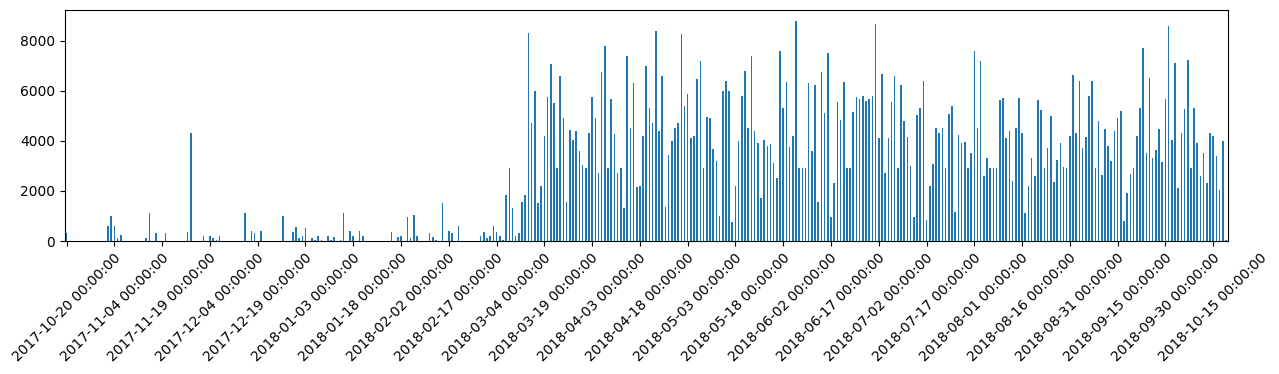

In [17]:
ax = y_filled.plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  # настрраиваем подписи по оси X
plt.xticks(rotation=45)

plt.show()

In [18]:
# определяем дату, начиная с которой данные будут отнесены к тестовой выборке
cutoff_date = y_filled.index.max()-pd.Timedelta(days=30) # последение 30 дней оставляем на тест

# делим данные на train и test
y_train = y_filled[y_filled.index <= cutoff_date]
y_test = y_filled[y_filled.index > cutoff_date]

display(y_train.shape,
        y_test.shape)

display(y_train.tail(2),
        y_test.head(2))

(335,)

(30,)

2018-09-18   1900.00
2018-09-19   2690.00
Freq: D, Name: full_sum, dtype: float64

2018-09-20   2901.00
2018-09-21   4170.00
Freq: D, Name: full_sum, dtype: float64

<a id='Обучение-SARIMAX'></a> 
## Обучение SARIMAX
[К содержанию](#К-содержанию)

Обучим SARIMAX для слабого прогнозирования ряда на несколько дней вперед:

In [19]:
# функция кросс-валидаци для подбора гиперпараметров SARIMAX
def cross_validate_sarima(data, order, seasonal_order, n_splits=15):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores = []
    smape_scores = []
    best_model = None
    best_rmse = np.inf
    
    data = data.asfreq('D')
    
    for train_index, test_index in tscv.split(data):
        train = data.iloc[train_index]
        test = data.iloc[test_index]
        
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False, 
                            maxiter=1000,
                            optim_score='harvey',
                            method='powell',
                            cov_type='robust')
        
        # делаем прогноз
        forecast = results.get_forecast(steps=len(test))
        predicted_mean = forecast.predicted_mean

        # cчитаем RMSE
        current_rmse = np.sqrt(mean_squared_error(test, predicted_mean))
        rmse_scores.append(current_rmse)
        
        # cчитаем SMAPE
        current_smape = smape(test, predicted_mean)
        smape_scores.append(current_smape)

        # сохраняем лучший вариант метрики и модели
        if current_rmse < best_rmse:
            best_rmse = current_rmse
            #best_smape = current_smape
            best_model = results
    
    # dозвращаем средние значения RMSE и SMAPE
    return np.nanmean(rmse_scores), np.nanmean(smape_scores), best_model

# задаем наборы гиперпараметров для SARIMAX
param_sets = [
    
    ((1, 1, 0), (0, 1, 1, 7)),  # упрощенная модель
    ((0, 1, 1), (0, 1, 1, 7)),  # базовый вариант
    ((1, 0, 0), (1, 1, 0, 7)),  # AR-структура
    ((0, 1, 2), (0, 1, 1, 7)),  # с увеличенным MA
    ((0, 1, 1), (1, 1, 1, 7)),  # с сезонным AR
    ((1, 1, 7), (0, 0, 0, 0)),  # ручной вариант
    ((1, 1, 2), (0, 0, 0, 0))   # ручной вариант 2
]

# перебор параметров
best_model_overall = None
best_rmse_overall = np.inf
best_smape_overall = np.inf

for param in param_sets:
    
    average_rmse, average_smape, best_model = cross_validate_sarima(
        y_train,
        param[0],
        param[1]
    )
    print(f"Средние значения метрик для набора параметров {param}: "
          f"RMSE - {average_rmse:.3f} SMAPE: {average_smape:.2f}")

    if average_rmse < best_rmse_overall:
        best_rmse_overall = average_rmse
        best_model_overall = best_model
        best_smape_overall = average_smape
    

Средние значения метрик для набора параметров ((1, 1, 0), (0, 1, 1, 7)): RMSE - 1900.862 SMAPE: 93.51
Средние значения метрик для набора параметров ((0, 1, 1), (0, 1, 1, 7)): RMSE - 100568567362.396 SMAPE: 82.08
Средние значения метрик для набора параметров ((1, 0, 0), (1, 1, 0, 7)): RMSE - 1770.433 SMAPE: 93.21
Средние значения метрик для набора параметров ((0, 1, 2), (0, 1, 1, 7)): RMSE - 2018290310802.765 SMAPE: 81.99
Средние значения метрик для набора параметров ((0, 1, 1), (1, 1, 1, 7)): RMSE - 34007441429134.301 SMAPE: 81.84
Средние значения метрик для набора параметров ((1, 1, 7), (0, 0, 0, 0)): RMSE - 1518.452 SMAPE: 76.18
Средние значения метрик для набора параметров ((1, 1, 2), (0, 0, 0, 0)): RMSE - 1492.912 SMAPE: 76.57


In [20]:
# переобучаем лучшую модель на полном тренировочном наборе
best_model_final = SARIMAX(
    y_train,
    order=best_model_overall.model.order,
    seasonal_order=best_model_overall.model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f'Лучшая модель с RMSE {best_rmse_overall:.3f} обучена на всех данных')

Лучшая модель с RMSE 1492.912 обучена на всех данных


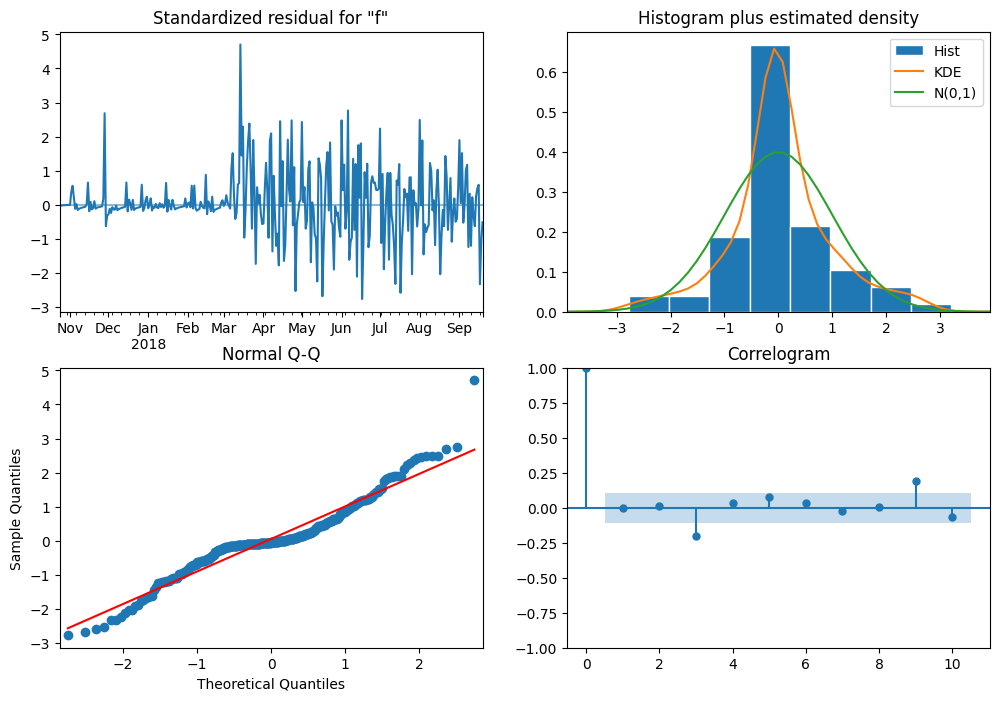

In [21]:
best_model_final.plot_diagnostics(figsize=(12, 8))
plt.show()

<a id='Тестирование-модели'></a> 
## Тестирование модели
[К содержанию](#К-содержанию)

Метрика RMSE на тестовых данных: 1884.55
Метрика SMAPE на тесовых данных: 37.95


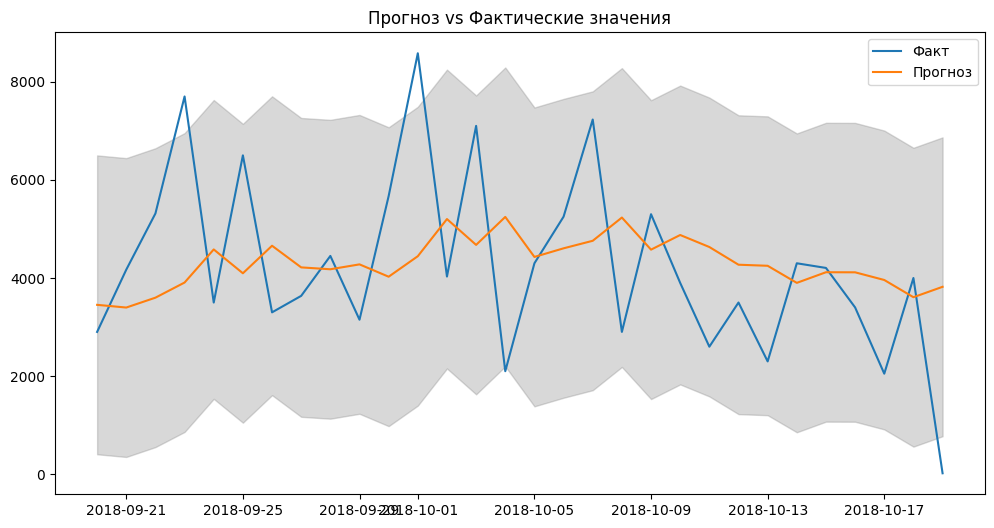

In [22]:
# объявляем прогнозные массивы
forecast_array = []
confidence_array = []

# рекурсивное прогнозирование
for step in range(len(y_test)):
    # генерация прогноза
    forecast = best_model_final.get_forecast(steps=1)
    forecast_array.append(forecast.predicted_mean.iloc[0])
    confidence_array.append(forecast.conf_int().iloc[0])
    
    # подготовка новых данных
    new_date = y_train.index.max() + pd.Timedelta(days=1)
    new_value = y_test.iloc[step]
    
    # создание объекта с правильным индексом
    new_data = pd.Series(
        new_value, 
        index=pd.date_range(new_date, periods=1, freq='D'),
        name='full_sum'
    )
    
    # обновление модели и данных
    best_model_final = best_model_final.append(new_data)
    y_train = pd.concat([y_train, new_data])

# постобработка результатов
forecast_series = pd.Series(forecast_array, index=y_test.index)
confidence_df = pd.DataFrame(confidence_array, index=y_test.index)

# считаем метрики RMSE и SMAPE
rmse_test = np.sqrt(mean_squared_error(y_test, forecast_series))
smape_test = smape(y_test, forecast_series)

print(f"Метрика RMSE на тестовых данных: {rmse_test:.2f}")
print(f"Метрика SMAPE на тесовых данных: {smape_test:.2f}")

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Факт')
plt.plot(forecast_series, label='Прогноз')
plt.fill_between(
    confidence_df.index,
    confidence_df.iloc[:, 0],
    confidence_df.iloc[:, 1],
    color='gray', alpha=0.3
)
plt.title('Прогноз vs Фактические значения')
plt.legend()
plt.show()

In [23]:
y_test.describe()

count     30.00
mean    4245.27
std     1858.00
min       20.00
25%     3187.50
50%     4015.00
75%     5287.50
max     8580.00
Name: full_sum, dtype: float64

**Вывод**

Сама по себе модель, обученная SARIMAX показала результат предсказания на уровне 1884 рубля по метрике RMSE и SMAPE на уровне 38% , что лучше среднего значения и на уровне стандартного распределения значений, попробуем добавить прогноз SARIMAX как признак для обучения catboost.